In [ ]:
import torch
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

train_data = datasets.FashionMNIST(
    root="Pytorch_Learn/FashionMNIST",
    train=True,
    download=True,
    transform=ToTensor()
)
test_data = datasets.FashionMNIST(
    root="Pytorch_Learn/FashionMNIST",
    train=False,
    download=True,
    transform=ToTensor()
)

Feature batch shape: torch.Size([64, 1, 28, 28])
Labels batch shape: torch.Size([64])
torch.Size([28, 28])


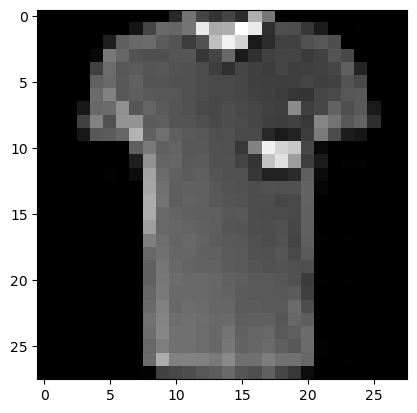

Label: 0


In [18]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(train_data, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=True)

# Display image and label.
train_features, train_labels = next(iter(train_dataloader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")
img = train_features[0].squeeze()
print(img.shape)
label = train_labels[0]
plt.imshow(img, cmap="gray")
plt.show()
print(f"Label: {label}")

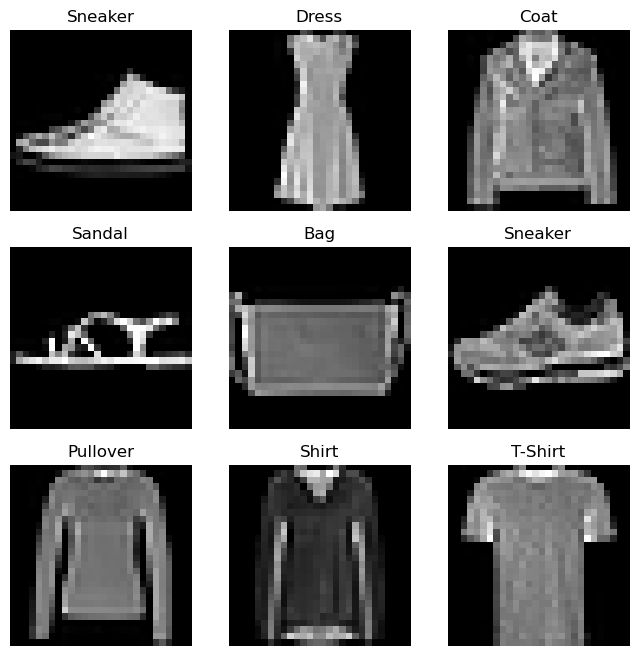

In [4]:
labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(train_data), size=(1,)).item()
    img, label = train_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

In [20]:
import pandas as pd
df = pd.read_csv("D:\Py_Code\Informer2020-main\ETT-small\ETTh1.csv")
print(type(df))
print(df.head())
print(len(df))

print(torch.randperm(10))

<class 'pandas.core.frame.DataFrame'>
                  date   HUFL   HULL   MUFL   MULL   LUFL   LULL         OT
0  2016-07-01 00:00:00  5.827  2.009  1.599  0.462  4.203  1.340  30.531000
1  2016-07-01 01:00:00  5.693  2.076  1.492  0.426  4.142  1.371  27.787001
2  2016-07-01 02:00:00  5.157  1.741  1.279  0.355  3.777  1.218  27.787001
3  2016-07-01 03:00:00  5.090  1.942  1.279  0.391  3.807  1.279  25.044001
4  2016-07-01 04:00:00  5.358  1.942  1.492  0.462  3.868  1.279  21.948000
17420
tensor([8, 1, 4, 2, 0, 3, 9, 6, 7, 5])


In [21]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


In [25]:
import os
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

In [26]:
model = NeuralNetwork().to(device)
print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


In [29]:
from torchsummary import summary
X = torch.rand(1, 28, 28, device=device)
logits = model(X)
pred_probab = nn.Softmax(dim=1)(logits)
print(pred_probab)
y_pred = pred_probab.argmax(1)
print(f"Predicted class: {y_pred}")
summary(model, input_size=(1, 28, 28))

tensor([[0.1006, 0.0994, 0.0957, 0.0963, 0.1042, 0.0938, 0.0927, 0.0997, 0.1125,
         0.1051]], device='cuda:0', grad_fn=<SoftmaxBackward0>)
Predicted class: tensor([8], device='cuda:0')
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                  [-1, 784]               0
            Linear-2                  [-1, 512]         401,920
              ReLU-3                  [-1, 512]               0
            Linear-4                  [-1, 512]         262,656
              ReLU-5                  [-1, 512]               0
            Linear-6                   [-1, 10]           5,130
Total params: 669,706
Trainable params: 669,706
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.02
Params size (MB): 2.55
Estimated Total Size (MB): 2.58
--------------------------------------------

In [32]:
# model layer
input_image = torch.rand(3, 28, 28)
print(input_image.size())
print(input_image.shape)

torch.Size([3, 28, 28])
torch.Size([3, 28, 28])


In [36]:
# nn.Flatten
flatten = nn.Flatten()
flt_image = flatten(input_image)
print(flt_image.size())

torch.Size([3, 784])


In [39]:
# nn.Linear
layer1 = nn.Linear(in_features=28 * 28, out_features=20)
hidden1 = layer1(flt_image)
print(hidden1.size())

torch.Size([3, 20])


In [40]:
# nn.ReLU
print(f"Before ReLU: {hidden1}\n\n")
hidden1 = nn.ReLU()(hidden1)
print(f"After ReLU: {hidden1}")

Before ReLU: tensor([[ 0.1403,  0.6696, -0.3042,  0.4276,  0.2857,  0.0262, -0.4206, -0.1342,
          0.2969,  0.0032,  0.0294, -0.1724,  0.4124, -0.1766,  0.0689, -0.4363,
         -0.2789, -0.1449,  0.1288, -0.4807],
        [ 0.3982,  0.6167, -0.4933,  0.2991,  0.3042, -0.0519, -0.3365, -0.0400,
          0.5051, -0.0310, -0.5954, -0.3108,  0.5151, -0.0202, -0.0313, -0.2994,
         -0.3257, -0.2703,  0.0614, -0.2315],
        [ 0.1540,  0.3283, -0.5204, -0.0282,  0.1056, -0.5381, -0.6367,  0.0263,
          0.0279,  0.0604, -0.0855, -0.2758,  0.3633, -0.1863,  0.0999, -0.2564,
         -0.5099, -0.2226, -0.0439, -0.1347]], grad_fn=<AddmmBackward0>)


After ReLU: tensor([[0.1403, 0.6696, 0.0000, 0.4276, 0.2857, 0.0262, 0.0000, 0.0000, 0.2969,
         0.0032, 0.0294, 0.0000, 0.4124, 0.0000, 0.0689, 0.0000, 0.0000, 0.0000,
         0.1288, 0.0000],
        [0.3982, 0.6167, 0.0000, 0.2991, 0.3042, 0.0000, 0.0000, 0.0000, 0.5051,
         0.0000, 0.0000, 0.0000, 0.5151, 0.0000, 0.00

In [41]:
# nn.Sequential
seq_modules = nn.Sequential(
    flatten,
    layer1,
    nn.ReLU(),
    nn.Linear(20, 10)
)
input_image = torch.rand(3,28,28)
logits = seq_modules(input_image)

In [43]:
# nn.Softmax
softmax = nn.Softmax(dim=1)
pred_probab = softmax(logits)
print(pred_probab)

tensor([[0.0996, 0.0939, 0.0823, 0.0937, 0.1046, 0.1447, 0.0921, 0.1259, 0.0877,
         0.0755],
        [0.1129, 0.1022, 0.0879, 0.0915, 0.0939, 0.1328, 0.0937, 0.1198, 0.0898,
         0.0755],
        [0.1164, 0.0999, 0.0887, 0.0910, 0.0869, 0.1370, 0.0976, 0.1154, 0.0853,
         0.0819]], grad_fn=<SoftmaxBackward0>)


In [45]:
# Model Parameters
print(f"Model structure: {model}\n\n")

for name, param in model.named_parameters():
    print(f"Layer: {name} | Size: {param.size()} | Values : {param[:2]} \n")

Model structure: NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


Layer: linear_relu_stack.0.weight | Size: torch.Size([512, 784]) | Values : tensor([[-0.0251,  0.0092, -0.0350,  ..., -0.0152, -0.0193,  0.0102],
        [-0.0065,  0.0231,  0.0260,  ..., -0.0192,  0.0139, -0.0029]],
       device='cuda:0', grad_fn=<SliceBackward0>) 

Layer: linear_relu_stack.0.bias | Size: torch.Size([512]) | Values : tensor([-0.0312, -0.0100], device='cuda:0', grad_fn=<SliceBackward0>) 

Layer: linear_relu_stack.2.weight | Size: torch.Size([512, 512]) | Values : tensor([[ 0.0087,  0.0162, -0.0323,  ..., -0.0221,  0.0030,  0.0324],
        [ 0.0327, -0.0167, -0.0313,  ..., -0.0275,  0.0120, -0.0441]],
       device='cuda:0', grad_fn=<Sl